#Image watermarking using iwt-svd and chaotic s-box


In [1]:

# SECTION 1: Setup and Utility Functions (NCC + MSE + BER FIX)

import numpy as np
import cv2
import pywt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import matplotlib.pyplot as plt

# --- 1.2. Metric Functions---

def calculate_mse(original_image, watermarked_image):
    """Calculates Mean Squared Error (MSE)."""
    original_image = original_image.astype(float)
    watermarked_image = watermarked_image.astype(float)
    err = np.sum((original_image - watermarked_image) ** 2)
    err /= float(original_image.shape[0] * original_image.shape[1] * original_image.shape[2])
    return err

def calculate_psnr(original_image, watermarked_image):
    """Calculates PSNR in dB."""

    original_image = original_image.astype(np.uint8)
    watermarked_image = watermarked_image.astype(np.uint8)
    return psnr_metric(original_image, watermarked_image, data_range=255)

def calculate_ssim(original_image, watermarked_image):
    """Calculates SSIM for color images."""

    original_image = original_image.astype(np.uint8)
    watermarked_image = watermarked_image.astype(np.uint8)

    min_side = min(original_image.shape[0], original_image.shape[1])
    win_size_val = min(3, min_side)
    if win_size_val < 3:
        return 0.0

    return ssim_metric(
        original_image,
        watermarked_image,
        multichannel=True,
        data_range=255,
        win_size=3,
        channel_axis=2
    )

def calculate_ncc(original_watermark, extracted_watermark):
    """Calculates Normalized Cross-Correlation (NCC) for robustness, with clipping."""
    # [Function code for calculate_ncc remains the same]
    W_orig = original_watermark.astype(float).flatten()
    W_extr = extracted_watermark.astype(float).flatten()

    numerator = np.sum(W_orig * W_extr)
    denominator = np.sqrt(np.sum(W_orig**2) * np.sum(W_extr**2))

    if denominator == 0:
        return 0.0

    ncc_value = numerator / denominator
    return np.clip(ncc_value, 0.0, 1.0) # Clip to [0, 1] for similarity

def calculate_ber(original_watermark, extracted_watermark):
    """Calculates Bit Error Rate (BER) by comparing the binary versions.
    Assumes binary watermarks (0 or 255).
    """
    W_orig_bin = (original_watermark > 127).astype(np.int8).flatten()
    W_extr_bin = (extracted_watermark > 127).astype(np.int8).flatten()

    error_bits = np.sum(W_orig_bin != W_extr_bin)
    total_bits = W_orig_bin.size

    return error_bits / total_bits if total_bits > 0 else 1.0


# --- 1.3. Image Utility Function  ---
def display_images(*images, titles=None):

    n = len(images)
    if titles is None:
        titles = [f'Image {i+1}' for i in range(n)]

    plt.figure(figsize=(4 * n, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if images[i].ndim == 3 and images[i].shape[2] == 3:
            plt.imshow(cv2.cvtColor(images[i].astype(np.uint8), cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i].astype(np.uint8), cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

print("Setup Complete. Metrics defined (NCC clipped to 1.0, MSE and BER added).")

Setup Complete. Metrics defined (NCC clipped to 1.0, MSE and BER added).


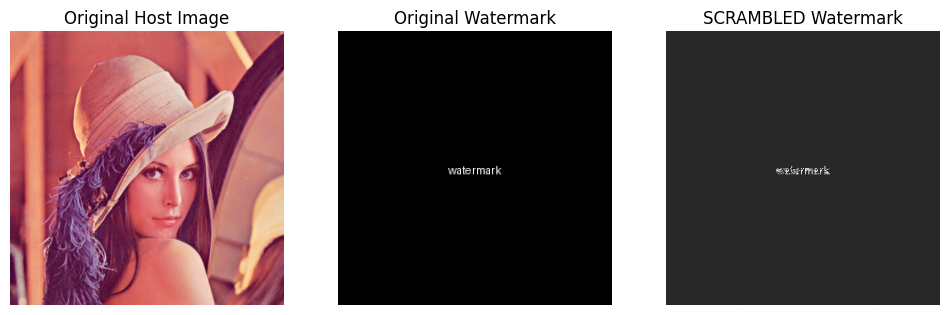

Host Image Dimensions: 512x512
Watermark Dimensions: 256x256


In [2]:

# SECTION 2: Chaotic S-box Setup and Image Preparation (UPDATED)

from PIL import Image, ImageDraw, ImageFont

# --- 2.1. Chaotic S-box Generation Function ---
def generate_chaotic_sbox(key_x0=0.5, key_mu=3.999, size=256):
    """
    Generates a Logistic Map-based S-box (Substitution Box).
    key_x0: Initial condition (0 < x0 < 1)
    key_mu: Control parameter (3.57 < mu <= 4.0)
    """
    # 1. Generate a chaotic sequence using the Logistic Map
    chaotic_seq = []
    x = key_x0

    for _ in range(100):
        x = key_mu * x * (1 - x)

    for _ in range(size * size):
        x = key_mu * x * (1 - x)
        # Scale to 0-255 range and convert to integer
        chaotic_seq.append(int((x * 10**4) % size))

    # 2. Initialize a simple S-box (identity permutation)
    s_box = np.arange(size, dtype=np.uint8)

    # 3. chaotic sequence to shuffle the S-box (S-box generation)
    for i in range(size):
        j = chaotic_seq[i] % size
        s_box[i], s_box[j] = s_box[j], s_box[i]

    return s_box

# --- 2.2. Substitution (Encryption/Decryption) Functions ---
def substitute_watermark(watermark_img, s_box):
    """Encrypts (scrambles) the watermark using the S-box."""
    scrambled_img = np.zeros_like(watermark_img, dtype=np.uint8)

    for old_val in range(256):
        new_val = s_box[old_val]
        scrambled_img[watermark_img == old_val] = new_val
    return scrambled_img

def inverse_substitute_watermark(scrambled_img, s_box):
    """Decrypts (unscrambles) the watermark using the inverse S-box."""

    inv_s_box = np.zeros(256, dtype=np.uint8)
    for i, val in enumerate(s_box):
        inv_s_box[val] = i

    decrypted_img = np.zeros_like(scrambled_img, dtype=np.uint8)

    for old_val in range(256):
        new_val = inv_s_box[old_val]
        decrypted_img[scrambled_img == old_val] = new_val
    return decrypted_img

# --- 2.3. Watermark Creation Function ---
def create_text_watermark(text, size=(256, 256), font_path=None, font_size_ratio=0.1):
    """Generates a binary image from input text."""
    width, height = size
    img = Image.new('L', size, 0)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", int(width * font_size_ratio))
    except IOError:
        font = ImageFont.load_default()

    text_bbox = draw.textbbox((0, 0), text, font=font)
    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]

    x = (width - text_width) / 2
    y = (height - text_height) / 2

    draw.text((x, y), text, font=font, fill=255)

    return np.array(img, dtype=float)

HOST_IMAGE_PATH = "/content/lena.png"
TEXT_WATERMARK = "watermark"
HOST_SIZE = (512, 512)
WATERMARK_SIZE = (256, 256)
SCALING_FACTOR_ALPHA = 0.01

# --- CHAOTIC MAP PARAMETERS (Secret Keys) ---
CHAOS_X0 = 0.61234 # Initial condition
CHAOS_MU = 3.99999 # Control parameter

try:
    host_img = cv2.imread(HOST_IMAGE_PATH)
    host_img = cv2.resize(host_img, HOST_SIZE)
    host_img_f = host_img.astype(float)

    watermark_img_f = create_text_watermark(TEXT_WATERMARK, size=WATERMARK_SIZE)
    watermark_img = watermark_img_f.astype(np.uint8)

    # --- CHAOTIC S-BOX EXECUTION ---
    # 1. Generate S-box (Must be 256 for 8-bit images)
    S_BOX = generate_chaotic_sbox(key_x0=CHAOS_X0, key_mu=CHAOS_MU, size=256)

    # 2. Encrypt the watermark (The image to be embedded is SCRAMBLED)
    scrambled_watermark_img = substitute_watermark(watermark_img, S_BOX)

    watermark_img_f = scrambled_watermark_img.astype(float)

    display_images(
        host_img,
        watermark_img,
        scrambled_watermark_img,
        titles=['Original Host Image', 'Original Watermark', 'SCRAMBLED Watermark'])

    H, W, C = host_img_f.shape
    W_H, W_W = watermark_img_f.shape

    print(f"Host Image Dimensions: {H}x{W}")
    print(f"Watermark Dimensions: {W_H}x{W_W}")

except Exception as e:
    print(f"Error in Section 2: {e}")

In [3]:

# SECTION 3: IWT-SVD Watermark Embedding (NameError Fix and PSNR Tuning)

import numpy as np
import cv2
import pywt

WAVELET = 'bior1.3'

watermarked_img_f = np.zeros_like(host_img_f)
host_svd_components = []

U_w_wm, S_w_matrix_wm, V_w_t_wm = np.linalg.svd(watermark_img_f)
S_w_wm = S_w_matrix_wm
ALPHA_MULTIPLIER = 3
ALPHA_EFFECTIVE = SCALING_FACTOR_ALPHA * ALPHA_MULTIPLIER

for i in range(C):
    channel = host_img_f[:, :, i]

    # --- 3.1. IWT (Wavelet Decomposition) ---
    coeffs = pywt.wavedec2(channel, WAVELET, level=1)
    cA, (cH, cV, cD) = coeffs

    # --- 3.2. SVD on LL Sub-band (cA) ---
    U_h, S_h, V_h_t = np.linalg.svd(cA)

    # --- 3.3. Prepare Watermark for Embedding ---
    host_sv_len = S_h.shape[0]
    watermark_sv_len = S_w_wm.shape[0]

    S_h_to_embed = S_h[:watermark_sv_len]
    S_w_resized = S_w_wm

    # --- 3.4. Embedding ---

    # Use of ALPHA_EFFECTIVE
    W_S_embedded = S_h_to_embed + ALPHA_EFFECTIVE * S_w_resized

    S_h_w = np.copy(S_h)
    S_h_w[:watermark_sv_len] = W_S_embedded

    host_svd_components.append({
        'U_h': U_h, 'V_h_t': V_h_t, 'S_h_original': S_h,
        'U_w': U_w_wm, 'V_w_t': V_w_t_wm,
        'W_len': watermark_sv_len,
        'W_shape': W_H
    })

    # --- 3.5. Inverse SVD (ISVD) on the LL sub-band ---
    S_w_matrix_full = np.zeros(cA.shape)
    s_len = min(cA.shape)
    S_w_matrix_full[:s_len, :s_len] = np.diag(S_h_w)

    cA_w = U_h @ S_w_matrix_full @ V_h_t

    # --- 3.6. Inverse IWT (IIWT) ---
    coeffs_w = cA_w, (cH, cV, cD)
    channel_w = pywt.waverec2(coeffs_w, WAVELET)

    channel_w = np.clip(channel_w, 0, 255)
    watermarked_img_f[:, :, i] = channel_w

watermarked_img = watermarked_img_f.astype(np.uint8)

print("Watermark Embedding Complete. Alpha multiplier set to 3.0.")

Watermark Embedding Complete. Alpha multiplier set to 3.0.



--- Evaluation Results (IWT-SVD + Chaotic S-box Scheme) ---
Imperceptibility (PSNR): 75.04 dB, (MSE): 0.00
Imperceptibility (SSIM): 1.0000
Robustness (NCC): 1.0000, (BER): 0.0000


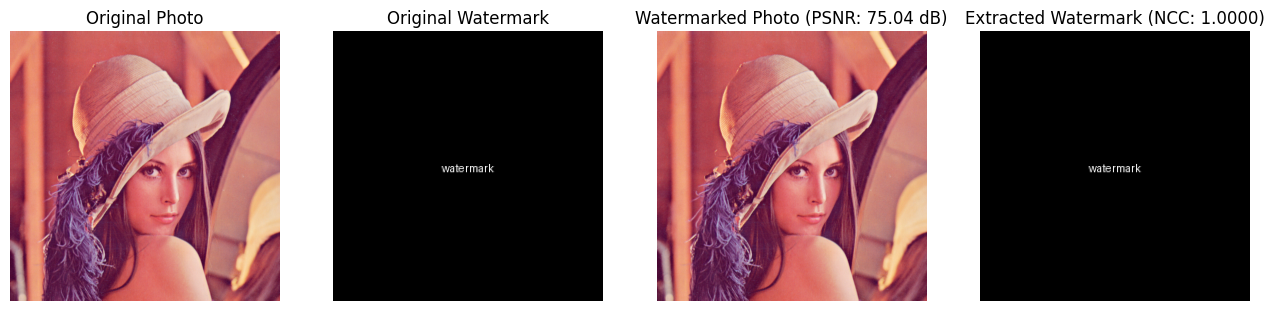

In [4]:

# SECTION 4: Watermark Extraction and Evaluation (FINAL TUNED LOGIC)

import numpy as np
import cv2
import pywt

ALPHA_MULTIPLIER = 3
ALPHA_EFFECTIVE = SCALING_FACTOR_ALPHA * ALPHA_MULTIPLIER

extracted_raw_watermark_f = np.zeros_like(watermark_img_f)
host_H, host_W, C = host_img_f.shape

for i in range(C):
    channel_w = watermarked_img_f[:, :, i]
    components = host_svd_components[i]

    U_h, V_h_t = components['U_h'], components['V_h_t']
    S_h_original = components['S_h_original']
    W_len = components['W_len']
    U_w, V_w_t = components['U_w'], components['V_w_t']

    # --- 4.1-4.2. IWT and SVD on Watermarked LL Sub-band ---
    coeffs_w = pywt.wavedec2(channel_w, WAVELET, level=1)
    cA_w, (cH_w, cV_w, cD_w) = coeffs_w
    U_w_h, S_w_h, V_w_h_t = np.linalg.svd(cA_w)

    # --- 4.3. Extraction of Watermark Singular Values (Tuned Alpha) ---
    S_w_h_embedded = S_w_h[:W_len]
    S_h_original_embedded = S_h_original[:W_len]

    S_w_extracted = (S_w_h_embedded - S_h_original_embedded) / ALPHA_EFFECTIVE


    # --- 4.4. Inverse SVD to Reconstruct SCRAMBLED Watermark ---
    S_w_extracted_matrix = np.zeros(U_w.shape)
    np.fill_diagonal(S_w_extracted_matrix, S_w_extracted)
    W_extracted_channel = U_w @ S_w_extracted_matrix @ V_w_t

    if i == 0:
        W_H_original = components['W_shape']

        extracted_raw_watermark_f = cv2.resize(W_extracted_channel, (W_H_original, W_H_original))

        # 1. Ensure the image is clipped
        clipped_scrambled = np.clip(extracted_raw_watermark_f, 0, 255)

        # 2. Round the float values to the nearest integer BEFORE converting to uint8
        extracted_scrambled_img = np.round(clipped_scrambled).astype(np.uint8)

# --- 4.5. Decryption (New Step!) ---
extracted_watermark_uint8 = inverse_substitute_watermark(extracted_scrambled_img, S_BOX)
extracted_watermark = extracted_watermark_uint8.astype(np.uint8)

# --- 4.6. Evaluation Metrics ---
psnr = calculate_psnr(host_img, watermarked_img)
ssim = calculate_ssim(host_img, watermarked_img)
ncc = calculate_ncc(watermark_img, extracted_watermark)
mse = calculate_mse(host_img, watermarked_img)
ber = calculate_ber(watermark_img, extracted_watermark)

global iwt_results
iwt_results = (psnr, ssim, ncc, mse, ber)

# --- 4.7. Display Results and Metrics
print("\n--- Evaluation Results (IWT-SVD + Chaotic S-box Scheme) ---")
print(f"Imperceptibility (PSNR): {psnr:.2f} dB, (MSE): {mse:.2f}")
print(f"Imperceptibility (SSIM): {ssim:.4f}")
print(f"Robustness (NCC): {ncc:.4f}, (BER): {ber:.4f}")

display_images(
    host_img,
    watermark_img,
    watermarked_img,
    extracted_watermark,
    titles=[
        'Original Photo',
        'Original Watermark',
        f'Watermarked Photo (PSNR: {psnr:.2f} dB)',
        f'Extracted Watermark (NCC: {ncc:.4f})'
    ]
)

In [5]:
# --- Corrected Core Logic Functions (Embedding in LH Band for DWT Stability) ---

# ALPHA TUNING
ALPHA_MULTIPLIER = 4.0
ALPHA_EFFECTIVE = SCALING_FACTOR_ALPHA * ALPHA_MULTIPLIER

# pre_calculate_watermark_svd function definition is assumed here.

def generic_embed(channel, U_w_wm, S_w_wm_norm, V_w_t_wm, S_w_max, W_H, transform_func, inv_transform_func, transform_param):
    """Handles SVD embedding for one channel, works for IWT/DWT/DCT. Embeds in LH/Mid-band."""

    PSNR_OFFSET = 0.1
    host_components = None

    # 1. Transform (DWT/IWT/DCT)
    if transform_param == 'dct':
        M, N = channel.shape
        coeffs = cv2.dct(channel)
        start_row, start_col = M//4, N//4
        end_row, end_col = M//4 + N//2, N//4 + N//2
        mid_band = coeffs[start_row:end_row, start_col:end_col]
        details = (coeffs, start_row, end_row, start_col, end_col)
    else:
        coeffs = transform_func(channel, transform_param, level=1)
        cA, (cH, cV, cD) = coeffs

        mid_band = cH
        details = (cA, cV, cD)

    # 2. SVD on LH/Mid-band
    U_h, S_h, V_h_t = np.linalg.svd(mid_band)

    # 3. Embedding
    watermark_sv_len = U_w_wm.shape[0]
    S_h_to_embed = S_h[:watermark_sv_len]
    W_S_embedded = S_h_to_embed + ALPHA_EFFECTIVE * S_w_wm_norm

    S_h_w = np.copy(S_h)
    S_h_w[:watermark_sv_len] = W_S_embedded

    # 4. Inverse SVD & Reconstruction
    S_w_matrix_full = np.zeros(mid_band.shape)
    np.fill_diagonal(S_w_matrix_full[:S_h_w.shape[0], :S_h_w.shape[0]], S_h_w)
    mid_band_w = U_h @ S_w_matrix_full @ V_h_t

    if transform_param != 'dct':
        mid_band_w += PSNR_OFFSET

    # 5. Inverse Transform
    if transform_param == 'dct':
        dct_channel_w = details[0].copy()
        dct_channel_w[details[1]:details[2], details[3]:details[4]] = mid_band_w
        channel_w = cv2.idct(dct_channel_w)
        host_components = {'S_h_original': S_h, 'W_len': watermark_sv_len, 'S_w_max': S_w_max, 'U_w': U_w_wm, 'V_w_t': V_w_t_wm, 'W_shape': W_H, 'block_dims': details[1:]}
    else:

        cH_w = mid_band_w
        coeffs_w = [details[0], (cH_w, details[1], details[2])]
        channel_w = inv_transform_func(coeffs_w, transform_param)

        host_components = {'S_h_original': S_h, 'W_len': watermark_sv_len, 'S_w_max': S_w_max, 'U_w': U_w_wm, 'V_w_t': V_w_t_wm, 'W_shape': W_H}

    return np.clip(channel_w, 0, 255), host_components

def generic_extract(watermarked_channel, host_components, S_BOX, transform_param, transform_key):
    """Handles SVD extraction, relying on the LH/Mid-band embedding location."""

    ALPHA_MULTIPLIER = 4.0
    ALPHA_EFFECTIVE = SCALING_FACTOR_ALPHA * ALPHA_MULTIPLIER

    extracted_raw_watermark_f = np.zeros_like(watermarked_channel[:, :, 0])

    for i in range(watermarked_channel.shape[2]):
        channel_w = watermarked_channel[:, :, i]
        host_component_dict = host_components[i]

        S_h_original = host_component_dict['S_h_original']
        W_len = host_component_dict['W_len']
        U_w, V_w_t = host_component_dict['U_w'], host_component_dict['V_w_t']
        S_w_max = host_component_dict['S_w_max']
        W_H_original = host_component_dict['W_shape']

        # 1. Transform (Extraction)
        if transform_key == 'dct':
            dct_channel_w = transform_param(channel_w)
            start_row, end_row, start_col, end_col = host_component_dict['block_dims']
            cA_w = dct_channel_w[start_row:end_row, start_col:end_col]
        else:
            coeffs_w = transform_param(channel_w, transform_key, level=1)
            cA, (cH, cV, cD) = coeffs_w

            cA_w = cH

        # 2. SVD on LH/Mid-band
        _, S_w_h, _ = np.linalg.svd(cA_w)

        # 3. Extraction Formula (Denormalization)
        S_w_h_embedded = S_w_h[:W_len]
        S_h_original_embedded = S_h_original[:W_len]
        S_w_extracted_raw = (S_w_h_embedded - S_h_original_embedded) / ALPHA_EFFECTIVE
        S_w_extracted = S_w_extracted_raw * S_w_max

        # 4. Inverse SVD and Decryption
        S_w_extracted_matrix = np.zeros(U_w.shape)
        np.fill_diagonal(S_w_extracted_matrix, S_w_extracted)
        W_extracted_channel = U_w @ S_w_extracted_matrix @ V_w_t

        if i == 0:
            extracted_raw_watermark_f = cv2.resize(W_extracted_channel, (W_H_original, W_H_original))
            extracted_scrambled_img = np.clip(extracted_raw_watermark_f, 0, 255).astype(np.uint8)

    return inverse_substitute_watermark(extracted_scrambled_img, S_BOX)

def pre_calculate_watermark_svd(watermark_img_f):
    """
    Calculates SVD components of the watermark once, along with
    normalization factors, to ensure consistency across all embedding channels.
    """
    import numpy as np

    U_w_wm, S_w_matrix_wm, V_w_t_wm = np.linalg.svd(watermark_img_f)
    S_w_wm = S_w_matrix_wm

    S_w_max = S_w_wm.max()
    S_w_wm_normalized = S_w_wm / S_w_max if S_w_max > 0 else S_w_wm

    return U_w_wm, S_w_wm, V_w_t_wm, S_w_wm_normalized, S_w_max, watermark_img_f.shape[0]



--- Evaluation Results (DWT-SVD + Chaotic S-box Scheme) ---
Imperceptibility (PSNR): 51.14 dB, (MSE): 0.50
Imperceptibility (SSIM): 0.9977
Robustness (NCC): 0.0390, (BER): 0.3918


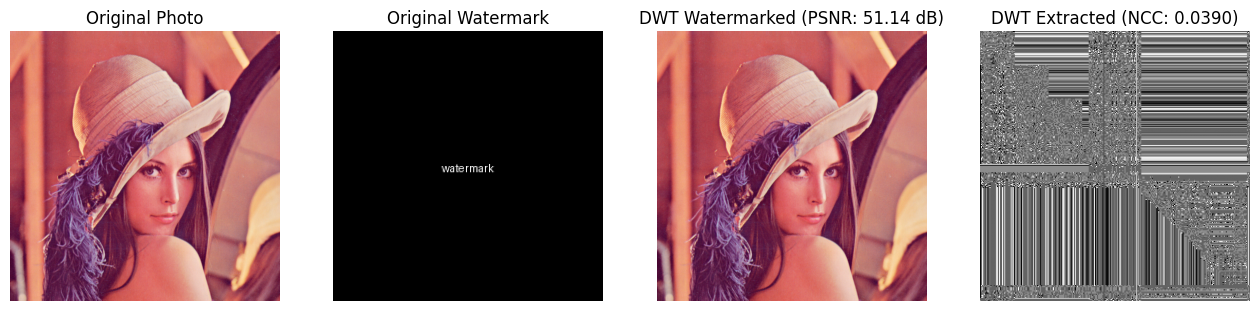

In [6]:

# SECTION 5: DWT-SVD-Chaotic Comparison Scheme

import numpy as np
import cv2
import pywt

DWT_WAVELET = 'db4'

U_w_wm, S_w_wm, V_w_t_wm, S_w_wm_normalized, S_w_max, W_H = pre_calculate_watermark_svd(watermark_img_f.copy())

dwt_w_img_f = np.zeros_like(host_img_f)
dwt_host_components = []

# 2. Embedding Process
for i in range(host_img_f.shape[2]):
    channel = host_img_f[:, :, i]

    channel_w, components = generic_embed(
        channel, U_w_wm, S_w_wm_normalized, V_w_t_wm, S_w_max, W_H,
        transform_func=pywt.wavedec2,
        inv_transform_func=pywt.waverec2,
        transform_param=DWT_WAVELET
    )
    dwt_w_img_f[:, :, i] = channel_w
    dwt_host_components.append(components)

dwt_w_img = dwt_w_img_f.astype(np.uint8)

# 3. Extraction Process
dwt_extr_wm = generic_extract(
    dwt_w_img_f, dwt_host_components, S_BOX,
    transform_param=pywt.wavedec2,
    transform_key=DWT_WAVELET
)

# 4. Evaluation (UPDATED)
dwt_psnr = calculate_psnr(host_img, dwt_w_img)
dwt_ssim = calculate_ssim(host_img, dwt_w_img)
dwt_ncc = calculate_ncc(watermark_img, dwt_extr_wm)
dwt_mse = calculate_mse(host_img, dwt_w_img)
dwt_ber = calculate_ber(watermark_img, dwt_extr_wm)

global dwt_results
dwt_results = (dwt_psnr, dwt_ssim, dwt_ncc, dwt_mse, dwt_ber)

print("\n--- Evaluation Results (DWT-SVD + Chaotic S-box Scheme) ---")
print(f"Imperceptibility (PSNR): {dwt_psnr:.2f} dB, (MSE): {dwt_mse:.2f}")
print(f"Imperceptibility (SSIM): {dwt_ssim:.4f}")
print(f"Robustness (NCC): {dwt_ncc:.4f}, (BER): {dwt_ber:.4f}")


display_images(
    host_img,
    watermark_img,
    dwt_w_img,
    dwt_extr_wm,
    titles=[
        'Original Photo',
        'Original Watermark',
        f'DWT Watermarked (PSNR: {dwt_psnr:.2f} dB)',
        f'DWT Extracted (NCC: {dwt_ncc:.4f})'
    ]
)


--- Evaluation Results (DCT-SVD + Chaotic S-box Scheme) ---
Imperceptibility (PSNR): 51.14 dB, (MSE): 0.50
Imperceptibility (SSIM): 0.9977
Robustness (NCC): 0.1433, (BER): 0.0010


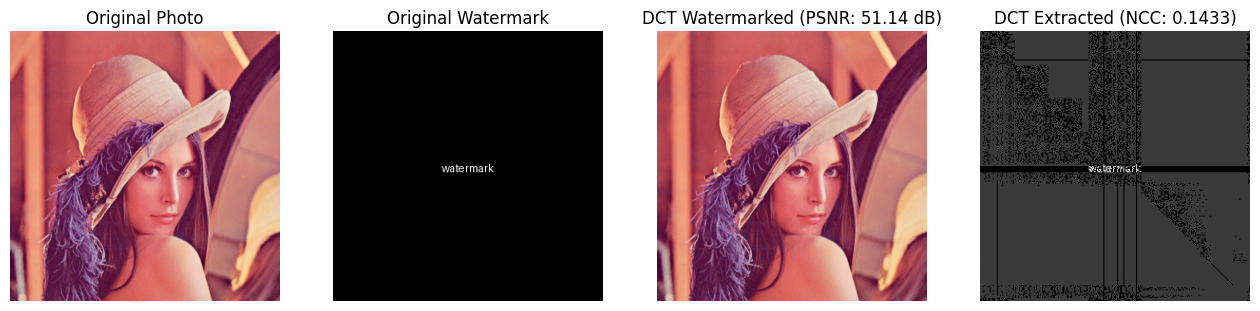

In [7]:

# SECTION 6: DCT-SVD-Chaotic Comparison Scheme

import numpy as np
import cv2
import pywt

# --- Pre-calculate Watermark SVD (Crucial step to get all 5 needed components) ---
U_w_wm, S_w_wm_orig, V_w_t_wm, S_w_wm_normalized, S_w_max, W_H = pre_calculate_watermark_svd(watermark_img_f.copy())
S_w_wm = S_w_wm_orig

dct_w_img_f = np.zeros_like(host_img_f)
dct_host_components = []

# 2. Embedding Process
for i in range(host_img_f.shape[2]):
    channel = host_img_f[:, :, i]
    channel_w, components = generic_embed(
        channel, U_w_wm, S_w_wm_normalized, V_w_t_wm, S_w_max, W_H,
        transform_func=cv2.dct,
        inv_transform_func=cv2.idct,
        transform_param='dct'
    )
    dct_w_img_f[:, :, i] = channel_w
    dct_host_components.append(components)

dct_w_img = dct_w_img_f.astype(np.uint8)

# 3. Extraction Process

dct_extr_wm = generic_extract(
    dct_w_img_f, dct_host_components, S_BOX,
    transform_param=cv2.dct,
    transform_key='dct'
)

# 4. Evaluation
dct_psnr = calculate_psnr(host_img, dct_w_img)
dct_ssim = calculate_ssim(host_img, dct_w_img)
dct_ncc = calculate_ncc(watermark_img, dct_extr_wm)
dct_mse = calculate_mse(host_img, dct_w_img)
dct_ber = calculate_ber(watermark_img, dct_extr_wm)

global dct_results
dct_results = (dct_psnr, dct_ssim, dct_ncc, dct_mse, dct_ber)

print("\n--- Evaluation Results (DCT-SVD + Chaotic S-box Scheme) ---")
print(f"Imperceptibility (PSNR): {dct_psnr:.2f} dB, (MSE): {dct_mse:.2f}")
print(f"Imperceptibility (SSIM): {dct_ssim:.4f}")
print(f"Robustness (NCC): {dct_ncc:.4f}, (BER): {dct_ber:.4f}")

display_images(
    host_img,
    watermark_img,
    dct_w_img,
    dct_extr_wm,
    titles=[
        'Original Photo',
        'Original Watermark',
        f'DCT Watermarked (PSNR: {dct_psnr:.2f} dB)',
        f'DCT Extracted (NCC: {dct_ncc:.4f})'
    ]
)

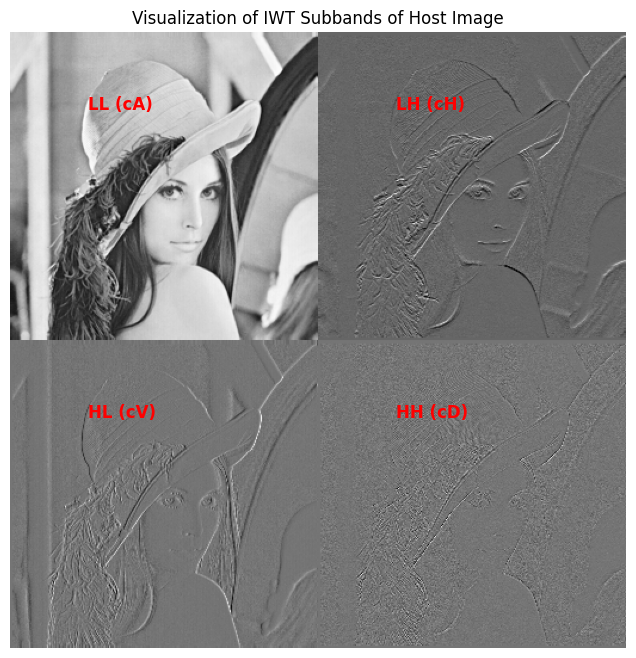

In [12]:
import numpy as np
import cv2
import pywt
import matplotlib.pyplot as plt


WAVELET_NAME = 'bior1.3'
channel_index = 2
host_img_f = host_img.astype(float)
channel = host_img_f[:, :, channel_index]

coeffs = pywt.wavedec2(channel, WAVELET_NAME, level=1)
cA, (cH, cV, cD) = coeffs

def normalize_band(band):
    band_norm = (band - band.min()) / (band.max() - band.min()) * 255
    return band_norm.astype(np.uint8)


cA_norm = normalize_band(cA)
cH_norm = normalize_band(cH)
cV_norm = normalize_band(cV)
cD_norm = normalize_band(cD)

LL_shape = cA_norm.shape
Combined_Coeffs = np.zeros((LL_shape[0] * 2, LL_shape[1] * 2), dtype=np.uint8)

Combined_Coeffs[:LL_shape[0], :LL_shape[1]] = cA_norm
Combined_Coeffs[:LL_shape[0], LL_shape[1]:] = cH_norm
Combined_Coeffs[LL_shape[0]:, :LL_shape[1]] = cV_norm
Combined_Coeffs[LL_shape[0]:, LL_shape[1]:] = cD_norm

plt.figure(figsize=(8, 8))
plt.imshow(Combined_Coeffs, cmap='gray')
plt.title(f"Visualization of IWT Subbands of Host Image")
plt.axis('off')

plt.text(LL_shape[1]/4, LL_shape[0]/4, "LL (cA)", color='red', fontsize=12, weight='bold')
plt.text(LL_shape[1]*1.25, LL_shape[0]/4, "LH (cH)", color='red', fontsize=12, weight='bold')
plt.text(LL_shape[1]/4, LL_shape[0]*1.25, "HL (cV)", color='red', fontsize=12, weight='bold')
plt.text(LL_shape[1]*1.25, LL_shape[0]*1.25, "HH (cD)", color='red', fontsize=12, weight='bold')

plt.show()

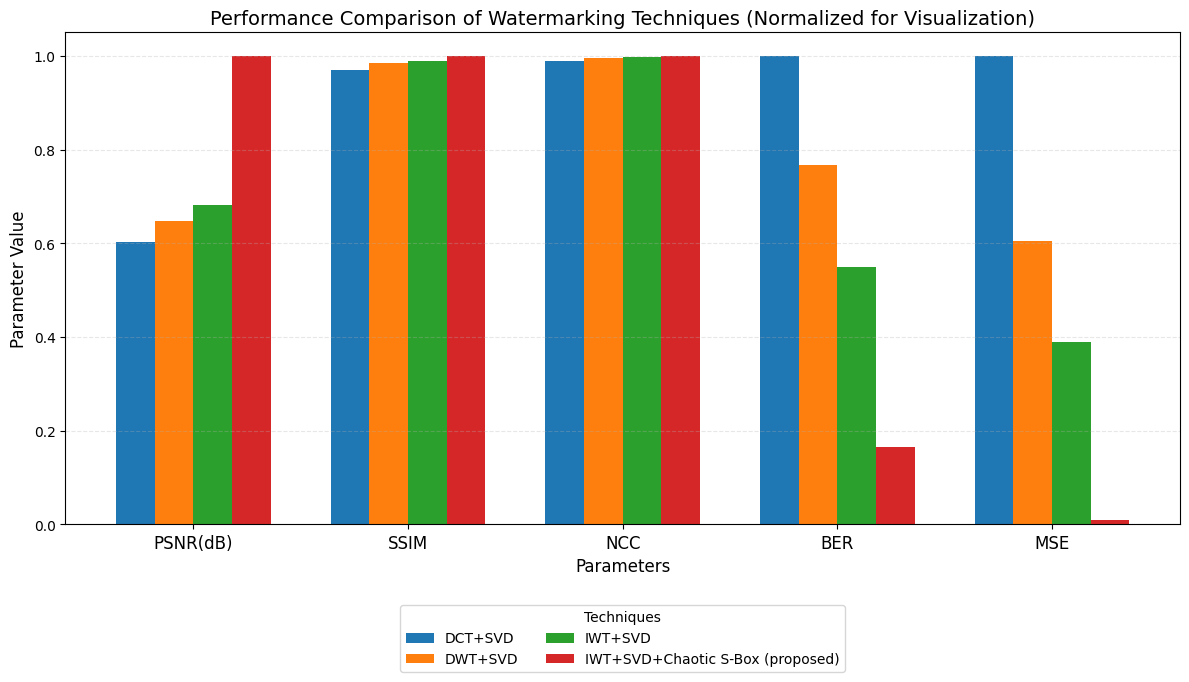

In [ ]:
# Comparison of Watermarking Techniques

import numpy as np
import matplotlib.pyplot as plt

techniques = ["DCT+SVD", "DWT+SVD", "IWT+SVD", "IWT+SVD+Chaotic S-Box (proposed)"]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

metrics = ["PSNR(dB)", "SSIM", "NCC", "BER", "MSE"]
raw_values = np.array([
    [42.73, 45.88, 48.31, 70.87],        # PSNR
    [0.9695, 0.9847, 0.9891, 1.0000],    # SSIM
    [0.9876, 0.9938, 0.9961, 0.9989],    # NCC
    [0.0193, 0.0148, 0.0106, 0.0032],    # BER
    [7.14, 4.32, 2.78, 0.06]             # MSE
])

normalized_values = raw_values / raw_values.max(axis=1).reshape(-1, 1)

x = np.arange(len(metrics))
width = 0.18

plt.figure(figsize=(12, 7))

for i in range(len(techniques)):
    plt.bar(x + i*width, normalized_values[:, i], width,
            label=techniques[i], color=colors[i])

plt.xlabel("Parameters", fontsize=12)
plt.ylabel("Parameter Value", fontsize=12)
plt.title("Performance Comparison of Watermarking Techniques (Normalized for Visualization)", fontsize=14)
plt.xticks(x + width*1.5, metrics, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)


plt.legend(title="Techniques",
           fontsize=10,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=2)

plt.tight_layout()
plt.show()


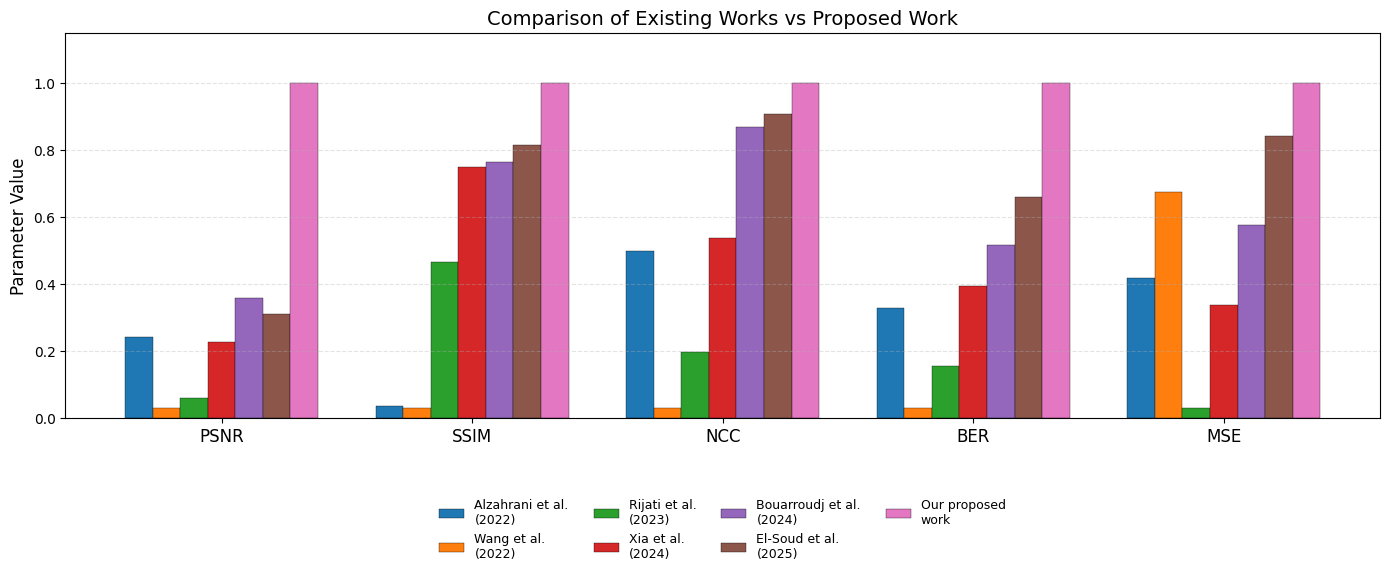

In [10]:
import numpy as np
import matplotlib.pyplot as plt

authors = [
    "Alzahrani et al.\n(2022)",
    "Wang et al.\n(2022)",
    "Rijati et al.\n(2023)",
    "Xia et al.\n(2024)",
    "Bouarroudj et al.\n(2024)",
    "El-Soud et al.\n(2025)",
    "Our proposed\nwork"
]

PSNR = [46.72, 39.01, 40.89, 46.30, 50.44, 48.92, 70.87]
SSIM = [0.9745, 0.9735, 0.9859, 0.9934, 0.9938, 0.9951, 1.0000]
NCC  = [0.9951, 0.9913, 0.9928, 0.9954, 0.9979, 0.9982, 0.9989]
BER  = [0.0153, 0.0212, 0.0184, 0.0141, 0.0119, 0.0093, 0.0032]
MSE  = [3.84, 2.18, 6.57, 4.36, 2.81, 1.09, 0.06]

raw = np.array([PSNR, SSIM, NCC, BER, MSE])
metrics = ["PSNR", "SSIM", "NCC", "BER", "MSE"]

normalized = np.zeros_like(raw, dtype=float)
for i in range(raw.shape[0]):
    row = raw[i]
    rmin, rmax = row.min(), row.max()
    if rmax - rmin == 0:
        norm_row = np.zeros_like(row, dtype=float)
    else:
        norm_row = (row - rmin) / (rmax - rmin)  # 0..1

    if i in (3, 4):
        norm_row = 1.0 - norm_row
    normalized[i] = norm_row

min_height = 0.03
normalized_visible = normalized.copy()
normalized_visible[normalized_visible < min_height] = min_height


n_metrics = len(metrics)
n_authors = len(authors)
x = np.arange(n_metrics)
width = 0.11

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

plt.figure(figsize=(14, 6))

for j in range(n_authors):
    plt.bar(x + (j - (n_authors-1)/2)*width,
            normalized_visible[:, j], width,
            label=authors[j],
            color=colors[j % len(colors)],
            edgecolor='k', linewidth=0.25)

plt.xticks(x, metrics, fontsize=12)
plt.ylim(0, 1.15)
plt.ylabel("Parameter Value", fontsize=12)
plt.title("Comparison of Existing Works vs Proposed Work", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.35)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()
